# Deconvolve the origins of replication

June 25, 2024

## Goal:
Deconvolve the origins of replication and show 1-2 great examples.

Procedure:
1. Load the chromatin deconvolution model.
2. Add a function to load the mnase and bins for the origin of replication

Note:
- We don't have the copy number correction scaling factor yet, it should not have a big effect on the chromatin, but something to keep in mind and place on the to do list.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [1]:
from src.config import load_combined_gene_expression_by_config_type, load_configs_by_config_type

config_type = 'shared'

chrom_config1, chrom_config2 = load_configs_by_config_type(config_type,
    with_copy_correction=True)


In [157]:
from src.combined_chromatin_model import CombinedChromatinModel

combined_model = CombinedChromatinModel(chrom_config1, chrom_config2)


In [158]:
combined_model.load_combined_mnase_orc('ARS1623')

Applying a normalization for length distribution
Applying a normalization for length distribution


In [161]:
combined_model.setup_deconv_model()

In [163]:
combined_model.deconvolve()

Deconvolving combined model with gamma=0.006
Deconvolving bin size: 24x24
of G shape: (31, 830)
Deconvolving with gamma=0.006
0/830 - 00:00:00.126
100/830 - 00:00:11.544
200/830 - 00:00:22.053
300/830 - 00:00:32.526
400/830 - 00:00:43.108
500/830 - 00:00:53.902
600/830 - 00:01:04.875
700/830 - 00:01:15.799
800/830 - 00:01:26.998
Deconvolved in : 00:01:31.348
The fitting norm is 14.48, the smoothing norm is: 30.63


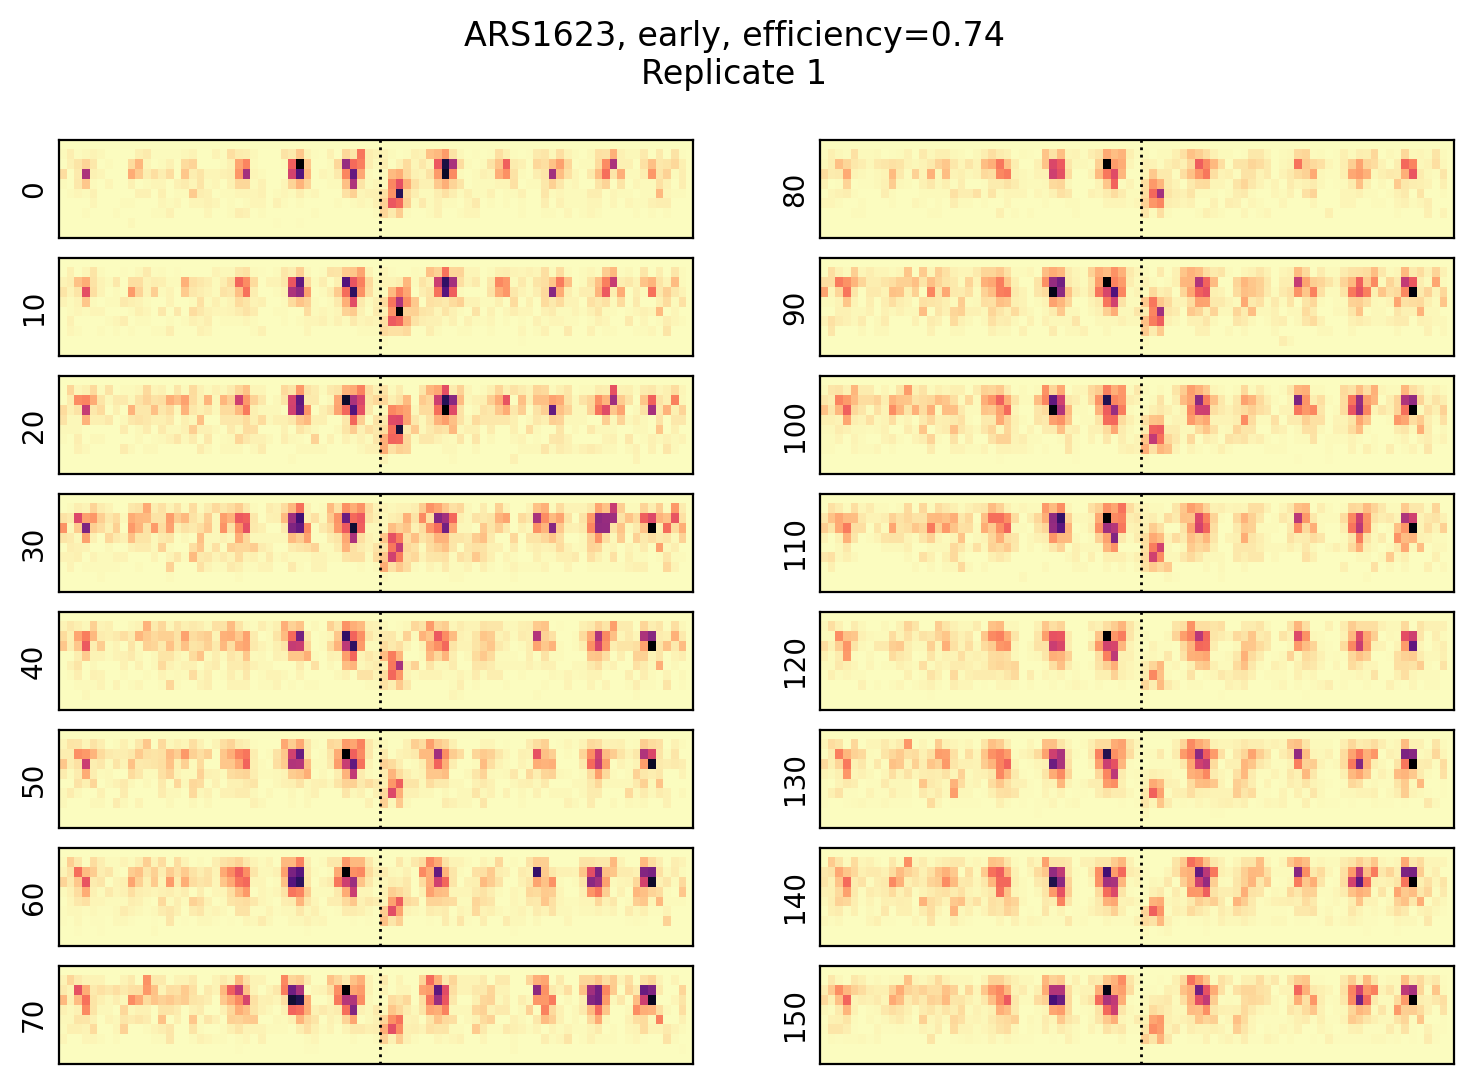

In [177]:
combined_model.chrom1_model.plot_raw_orc_data()

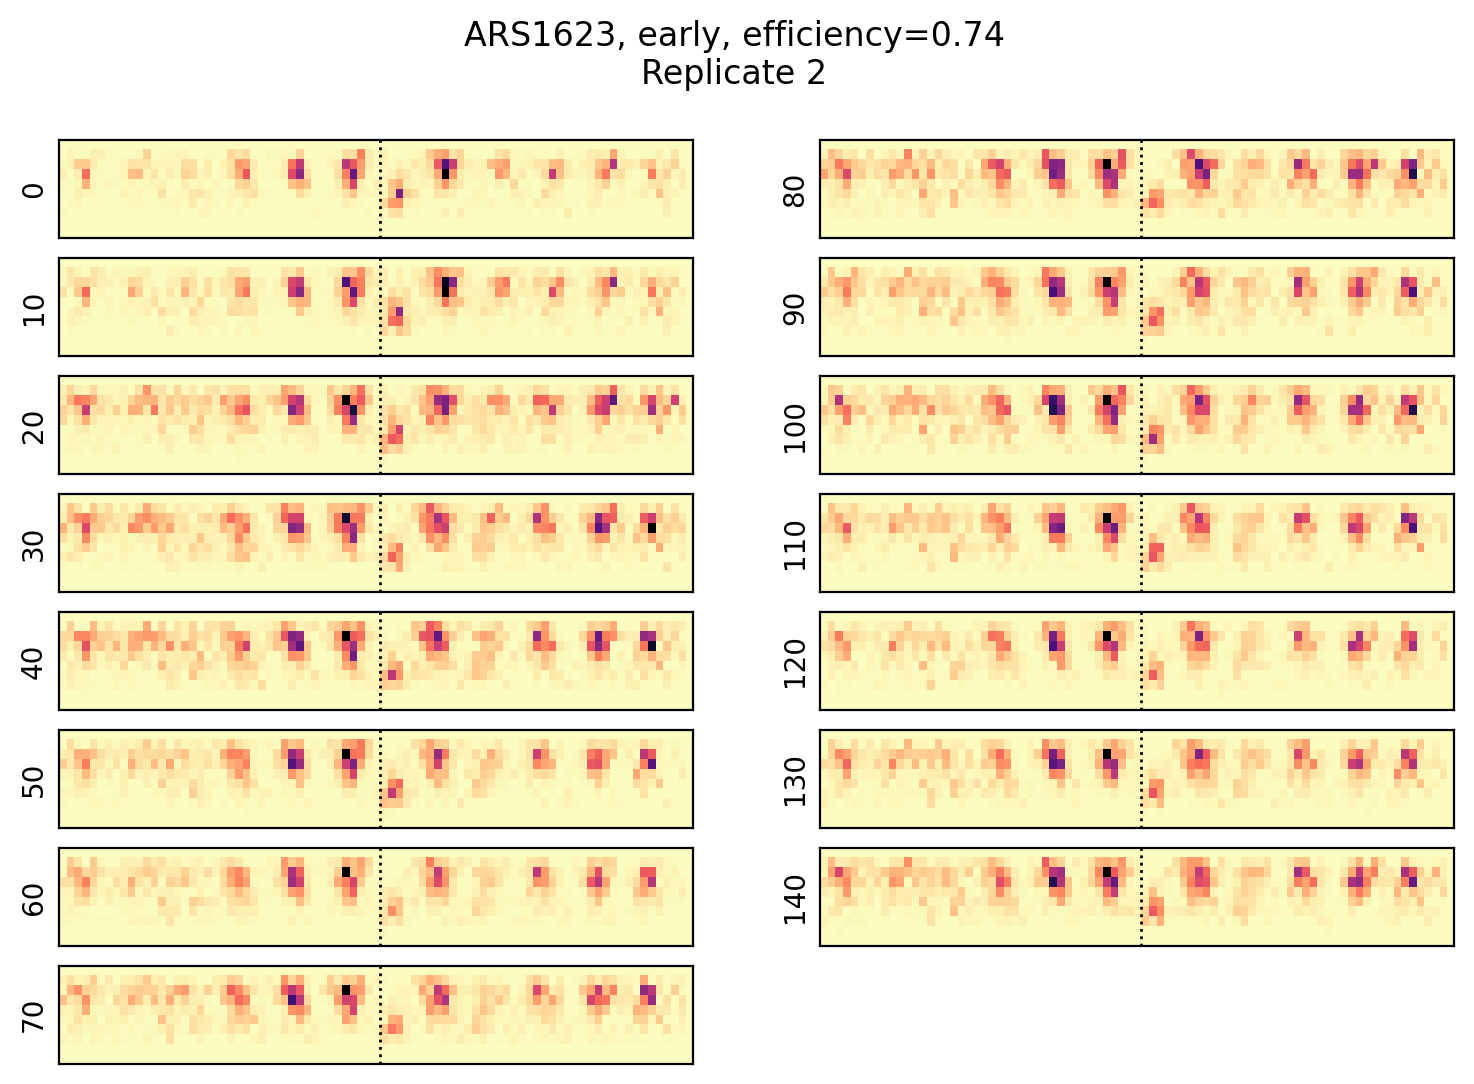

In [244]:
combined_model.chrom2_model.plot_raw_orc_data()

In [375]:
combined_model.chrom1_model.find_origin_postg1_nuc_position()

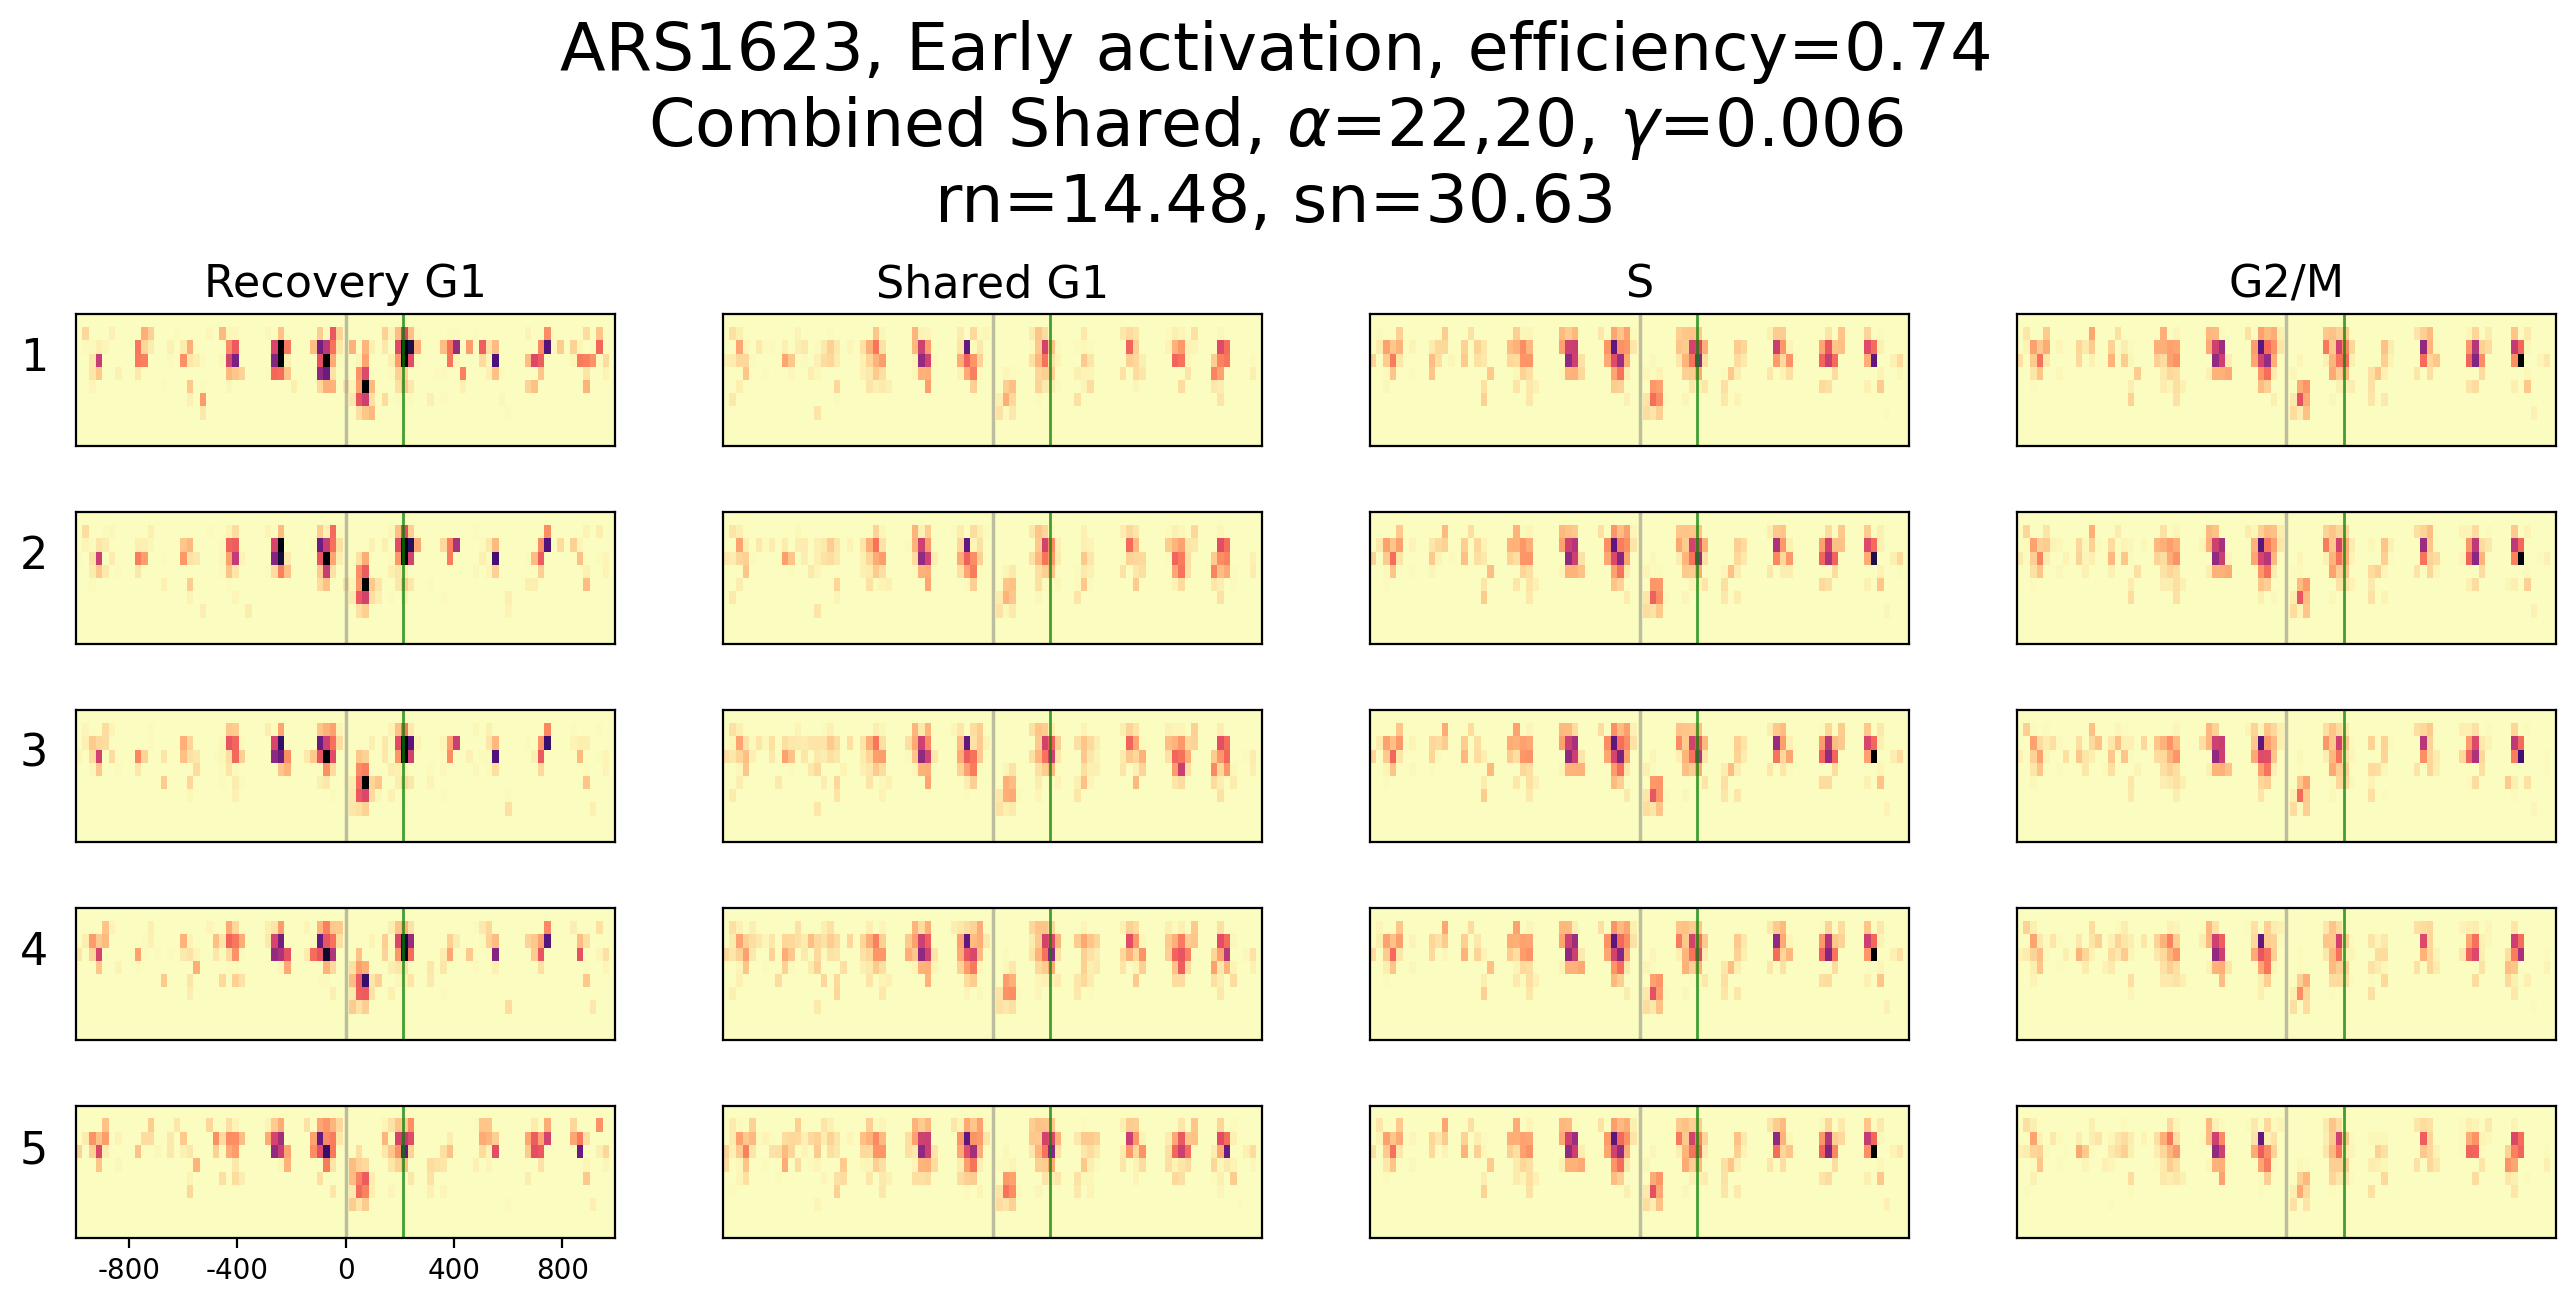

In [398]:
fig = combined_model.create_deconvolution_plots_abbreviated_flipped(vmax=75)

In [539]:
combined_model.chrom1_model.find_origin_postg1_nuc_position()
combined_model.chrom2_model.find_origin_postg1_nuc_position()

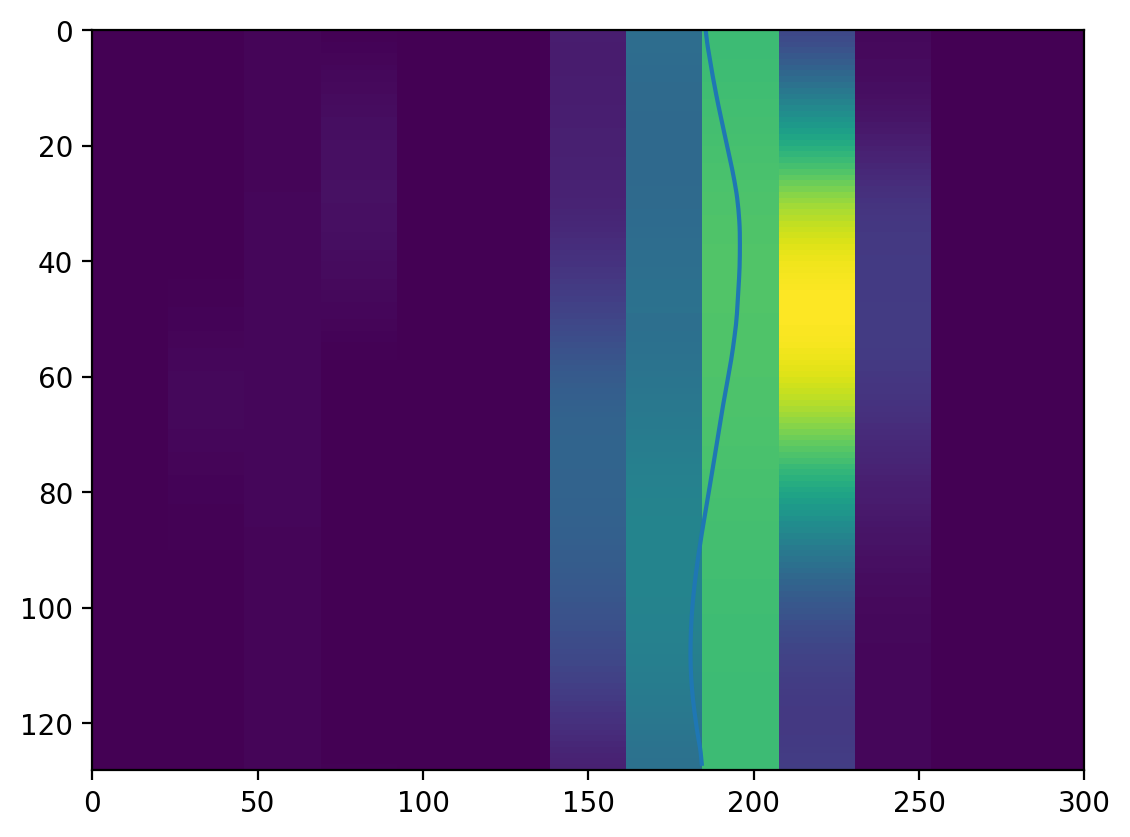

In [540]:
chrom_model = combined_model.chrom1_model

# g1_i = chrom_config1.get_Hpositions_for_phase('CG1')
# s_i = chrom_config1.get_Hpositions_for_phase('S')
# g2m_i = chrom_config1.get_Hpositions_for_phase('G2M')

center = (chrom_model.bin_extents[1]+
          chrom_model.bin_extents[0])/2 - chrom_model.bin_extents[0]

p1_pos = chrom_model.origin_plus_one_nuc_positions[t_indices]\
    - chrom_model.bin_extents[0]
p1_pos = p1_pos - center

m = len(p1_pos)

plt.imshow(chrom_model.origin_p1_nuc_bins[t_indices], 
    extent=[chrom_model.p1_nuc_x_span[0]-center, 
            chrom_model.p1_nuc_x_span[1]-center,
           0, m], aspect='auto', interpolation='none', origin='lower')

plt.ylim(m, 0)
plt.plot(p1_pos, np.arange(len(p1_pos)))


In [565]:

# # Get the plus one nucleosome positions
# # adjust for the genomic window and the p1 search span
# p1_nuc_positions_bp = chrom_model.origin_plus_one_nuc_positions
# p1_nuc_positions_bp = p1_nuc_positions_bp - chrom_model.bin_extents[0]\
#     - chrom_model.p1_nuc_x_span[0]
# p1_nuc_positions_bins = p1_nuc_positions_bp / GlobalConstants.BIN_WIDTH

# # Determine if the p1 nucleosome is correctly identifying the weighted mean properly
# # For each timepoint plot a histogram or density of the mass and the location of the predicted
# # weighted mean


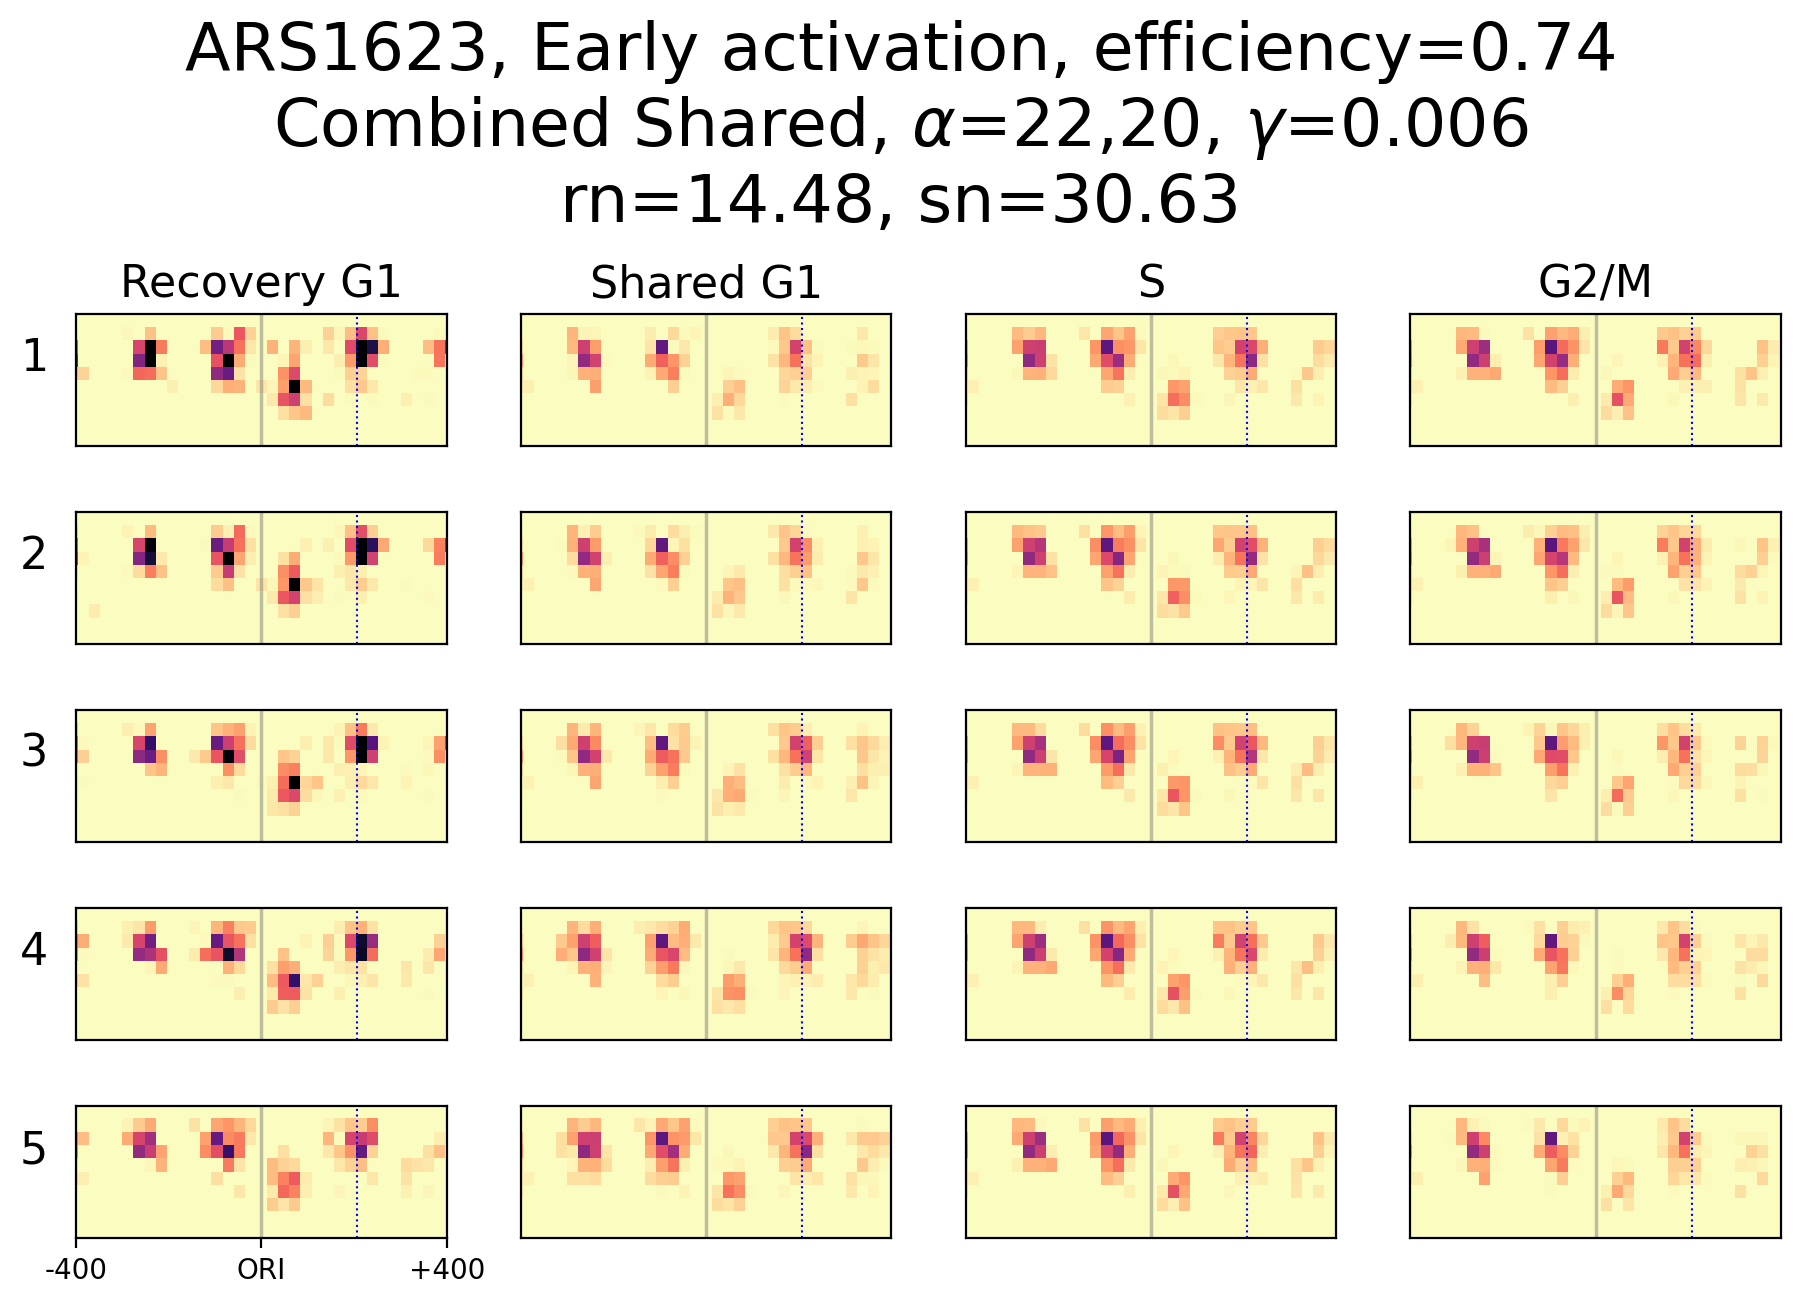

In [438]:
fig = combined_model.create_deconvolution_plots_abbreviated_flipped(zoom=800, vmax=75)


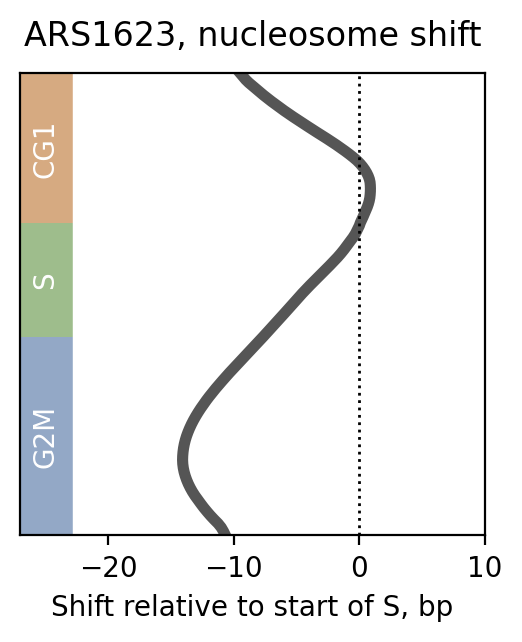

In [432]:
combined_model.chrom1_model.plot_nucleosome_shift()

In [586]:
chrom_model.find_origin_postg1_nuc_position()

In [594]:
x_bin_starts = np.arange(chrom_model.bin_extents[0], chrom_model.bin_extents[1], 24)
p1_span = chrom_model.p1_nuc_x_span

In [595]:
nuc_bin_sums = pd.DataFrame(chrom_model.nuc_bins_sum.T, index=pd.Index(x_bin_starts, 
    name='bin_start'))
p1_nuc_bin_sums = nuc_bin_sums.loc[p1_span[0]:p1_span[1]].copy()

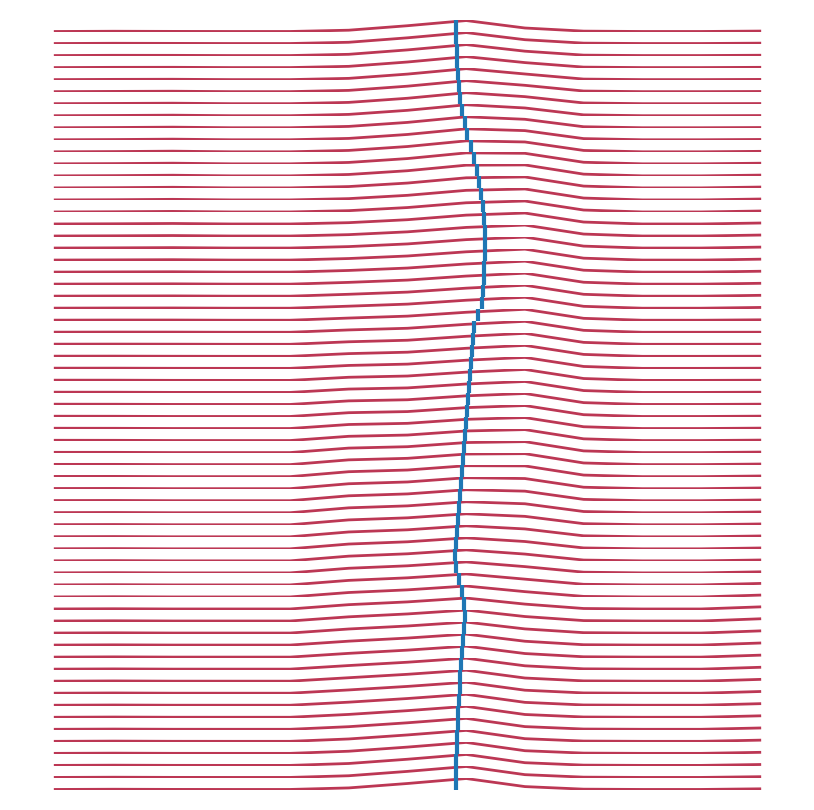

In [648]:
# Let's start with a plot of the p1 nucleosome mass over time
t_indices = chrom_model.config.get_Hpositions_for_branch('t')
p1_nuc_occs_during_t_branch = p1_nuc_bin_sums[t_indices]

from src.helpers import weighted_mean
p1_nuc_calling_wm = np.apply_along_axis(
    lambda row: weighted_mean(p1_nuc_occs_during_t_branch.index, row), 0, 
    p1_nuc_occs_during_t_branch.values)
p1_nuc_calling_wm = pd.Series(p1_nuc_calling_wm, index=p1_nuc_occs_during_t_branch.columns)
p1_nuc_calling_max = p1_nuc_occs_during_t_branch.idxmax(axis=0)

m = p1_nucs_during_t_branch.shape[1]
ms = range(0, m, 2)
num_rows = len(ms)

plt.figure(figsize=(5, 5))
plt.subplots_adjust(hspace=0.)
row = 1
for i in ms:
    plt.subplot(num_rows, 1, row)
    color = plt.get_cmap('inferno')(0.5)
    
    column_in_H = t_indices[i]
    p1_nuc_call = p1_nuc_calling_wm.iloc[i]

    xs = p1_nucs_during_t_branch[column_in_H].index
    ys = p1_nucs_during_t_branch[column_in_H]

    plt.plot(xs, ys, c=color, alpha=1., lw=1)
    
    plt.axvline(p1_nuc_call)
    
    row = row+1
    plt.xticks([])
    plt.yticks([])
    from src.plot_helpers import hide_spines
    hide_spines(plt.gca())


(128.0, 0.0)

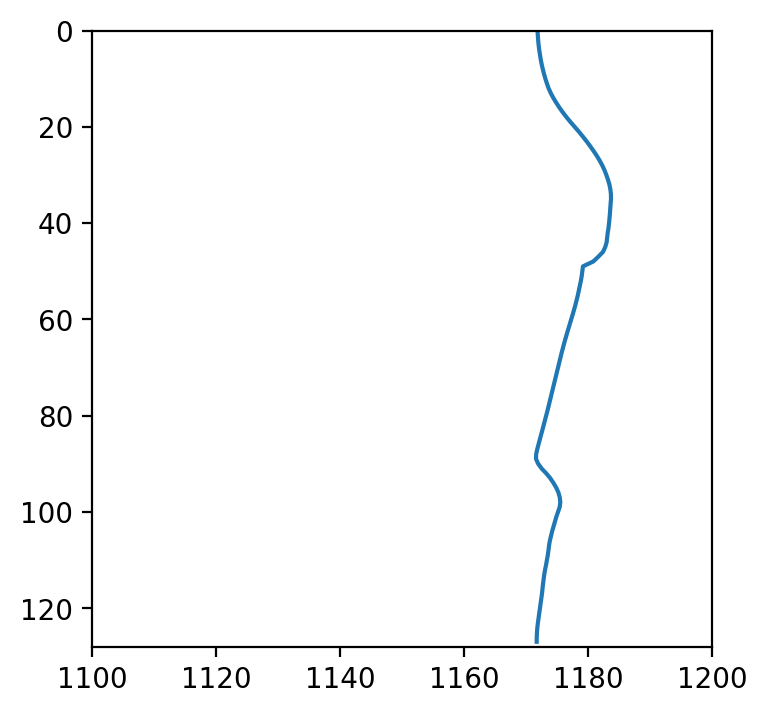

In [642]:
plt.figure(figsize=(4, 4))
plt.plot(p1_nuc_calling_wm - chrom_model.bin_extents[0], np.arange(m))
plt.xlim(1100, 1200)
plt.ylim(m, 0)